# Day 14: Natural Language Processing with LSTMs

## Tokenization, Padding, Embeddings, Sequence Models, Inference, and Embedding Visualization

This notebook introduces an end-to-end NLP classification pipeline using TensorFlow and Keras.

Students will learn:

- Why raw text cannot be sent directly into a neural network
- How tokenization converts words into integers
- How padding creates equal-length sequences
- How an Embedding layer converts words into dense vectors
- How an LSTM processes text in sequence
- How to train a binary text classifier
- How to evaluate the classifier on unseen text
- How to inspect prediction probabilities
- How to visualize learned word embeddings
- Why true text summarization requires an encoder-decoder architecture

Classification task:

```text
1 = NLP / Linguistics
0 = Vision / Spatial Computing
```

---

# Instructor Note

The original five-sentence dataset is too small for stable predictions.

This notebook uses a larger, balanced synthetic dataset so the outputs are easier for students to understand.

TensorFlow is usually pre-installed in Google Colab. If needed:

```python
!pip install tensorflow
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)

print("Day 14 NLP and LSTM Environment Initialized.")
print("TensorFlow version:", tf.__version__)

/Users/sai/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Day 14 NLP and LSTM Environment Initialized.
TensorFlow version: 2.16.2


---

# 1. The NLP Dataset

We use two balanced classes.

## Class 1: NLP / Linguistics

Examples include tokenization, parsing, syntax, translation, language models, and embeddings.

## Class 0: Vision / Spatial

Examples include images, object detection, LiDAR, 3D reconstruction, streetscape analysis, and point clouds.

In [2]:
abstracts = [
    "Exploring advanced morphological parsers for Dravidian languages",
    "A deep learning approach to Telugu syntax tree generation",
    "Part of speech tagging in low resource Indo Aryan scripts",
    "Tamil text tokenization using recurrent neural networks",
    "Kannada sentiment analysis with word embeddings",
    "Machine translation for morphologically rich languages",
    "Named entity recognition for Telugu news articles",
    "Building a language model for Malayalam text",
    "Automatic grammar correction for Hindi sentences",
    "Sequence labeling for multilingual linguistic datasets",
    "Subword segmentation for agglutinative languages",
    "LSTM based document classification for academic abstracts",
    "Computer vision metrics for 3D streetscape spatial analysis",
    "LiDAR point cloud processing for urban simulations",
    "Object detection in traffic surveillance images",
    "Semantic segmentation of road scenes using convolutional networks",
    "Three dimensional reconstruction from multiple camera views",
    "Image classification for handwritten assignment recognition",
    "Depth estimation for autonomous navigation systems",
    "Pose estimation for abnormal activity detection",
    "Satellite image analysis for urban planning",
    "Feature extraction from grayscale medical images",
    "Point cloud clustering for building detection",
    "OpenCV preprocessing for scanned document images"
]

labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
])

print("Total examples:", len(abstracts))
print("NLP examples:", np.sum(labels == 1))
print("Vision examples:", np.sum(labels == 0))

Total examples: 24
NLP examples: 12
Vision examples: 12


---

# 2. Train-Test Split

The training set is used to learn.

The test set is used only for final evaluation.

`stratify=labels` keeps both classes balanced.

In [3]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    abstracts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

print("Training examples:", len(X_train_text))
print("Testing examples:", len(X_test_text))
print("Training class counts:", np.bincount(y_train))
print("Testing class counts:", np.bincount(y_test))

Training examples: 18
Testing examples: 6
Training class counts: [9 9]
Testing class counts: [3 3]


---

# 3. Tokenization

A neural network cannot directly understand text strings.

The tokenizer creates a vocabulary and assigns each word an integer ID.

The special token `<OOV>` represents unseen words.

In [4]:
vocab_size = 1000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))
print("\nFirst 15 word-to-index mappings:")

for word, index in list(word_index.items())[:15]:
    print(f"{word:20s} -> {index}")

Vocabulary Size: 93

First 15 word-to-index mappings:
<OOV>                -> 1
for                  -> 2
images               -> 3
analysis             -> 4
languages            -> 5
from                 -> 6
telugu               -> 7
detection            -> 8
image                -> 9
recognition          -> 10
urban                -> 11
point                -> 12
cloud                -> 13
feature              -> 14
extraction           -> 15


---

# 4. Text to Integer Sequences

After building the vocabulary, every sentence becomes a sequence of word IDs.

These numbers are only identifiers. The Embedding layer will later learn useful vectors.

In [5]:
train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

for text, sequence in list(zip(X_train_text, train_sequences))[:3]:
    print("Original text:")
    print(text)
    print("Integer sequence:")
    print(sequence)
    print("-" * 70)

Original text:
Feature extraction from grayscale medical images
Integer sequence:
[14, 15, 6, 16, 17, 3]
----------------------------------------------------------------------
Original text:
Kannada sentiment analysis with word embeddings
Integer sequence:
[18, 19, 4, 20, 21, 22]
----------------------------------------------------------------------
Original text:
A deep learning approach to Telugu syntax tree generation
Integer sequence:
[23, 24, 25, 26, 27, 7, 28, 29, 30]
----------------------------------------------------------------------


---

# 5. Padding

Sentences have different lengths, but neural networks expect rectangular matrices.

Padding adds zeros so all sequences have the same length.

`padding="post"` adds zeros at the end.

In [6]:
max_length = 12

X_train = pad_sequences(
    train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training matrix shape:", X_train.shape)
print("Testing matrix shape:", X_test.shape)
print("\nFirst padded sequence:")
print(X_train[0])

Training matrix shape: (18, 12)
Testing matrix shape: (6, 12)

First padded sequence:
[14 15  6 16 17  3  0  0  0  0  0  0]


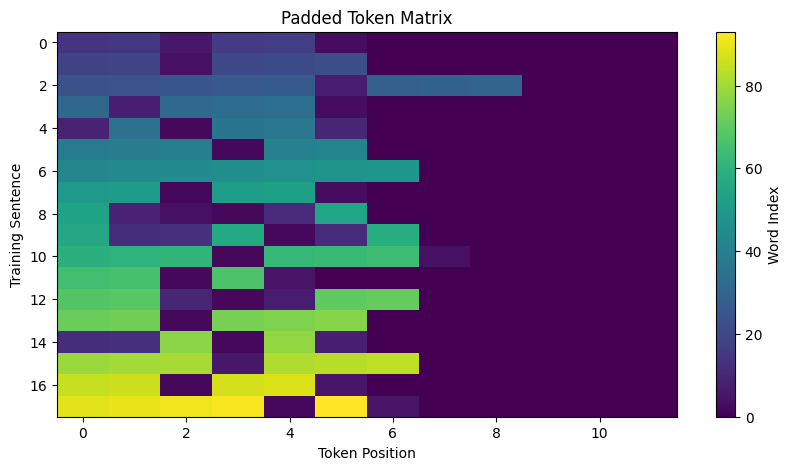

In [7]:
plt.figure(figsize=(10, 5))
plt.imshow(X_train, aspect="auto", cmap="viridis")
plt.title("Padded Token Matrix")
plt.xlabel("Token Position")
plt.ylabel("Training Sentence")
plt.colorbar(label="Word Index")
plt.show()

---

# 6. Building the LSTM Model

The model contains:

1. Input layer
2. Embedding layer
3. LSTM layer
4. Dropout layer
5. Dense classifier
6. Sigmoid output

`mask_zero=True` tells the LSTM to ignore padding zeros.

In [8]:
embedding_dim = 16

nlp_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

nlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

nlp_model.summary()

2026-06-18 09:17:29.073407: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-18 09:17:29.073570: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-18 09:17:29.073575: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-06-18 09:17:29.073758: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-18 09:17:29.073774: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 16)         │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)

---

# 7. Training

During training:

1. The model reads the padded sequences
2. It predicts a probability
3. Binary cross-entropy measures the error
4. Adam updates the weights
5. The process repeats across epochs

In [9]:
print("Initiating LSTM Training Sequence...")

history = nlp_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=4,
    validation_data=(X_test, y_test),
    verbose=0
)

print("Training Complete.")
print(f"Final Training Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

Initiating LSTM Training Sequence...


2026-06-18 09:17:33.202362: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Training Complete.
Final Training Accuracy: 100.00%
Final Validation Accuracy: 50.00%
Final Training Loss: 0.0005
Final Validation Loss: 3.0154


---

# 8. Training Curves

Good signs:

- Loss decreases
- Accuracy increases
- Validation performance follows training performance

Possible overfitting:

- Training accuracy rises
- Validation accuracy stops improving
- Validation loss increases

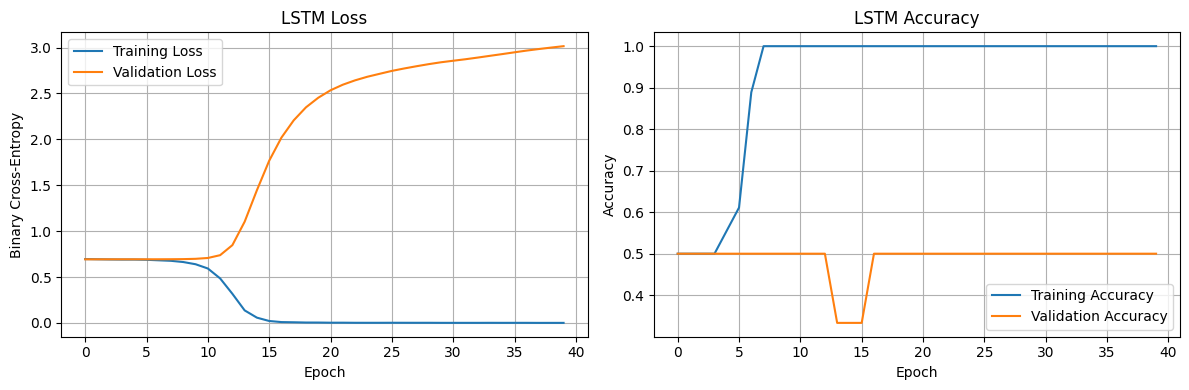

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Training Loss")
ax1.plot(history.history["val_loss"], label="Validation Loss")
ax1.set_title("LSTM Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Binary Cross-Entropy")
ax1.legend()
ax1.grid(True)

ax2.plot(history.history["accuracy"], label="Training Accuracy")
ax2.plot(history.history["val_accuracy"], label="Validation Accuracy")
ax2.set_title("LSTM Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---

# 9. Test Evaluation

Probability interpretation:

```text
Probability >= 0.5 → NLP / Linguistics
Probability < 0.5 → Vision / Spatial
```

In [11]:
test_probabilities = nlp_model.predict(X_test, verbose=0).flatten()
test_predictions = (test_probabilities >= 0.5).astype(int)

test_loss, test_accuracy = nlp_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

for text, actual, probability, predicted in zip(
    X_test_text,
    y_test,
    test_probabilities,
    test_predictions
):
    actual_name = "NLP/Linguistics" if actual == 1 else "Vision/Spatial"
    predicted_name = "NLP/Linguistics" if predicted == 1 else "Vision/Spatial"

    print("\nText:", text)
    print("Actual:", actual_name)
    print("Predicted:", predicted_name)
    print(f"NLP Probability: {probability:.4f}")

Test Loss: 3.0154
Test Accuracy: 50.00%

Text: Depth estimation for autonomous navigation systems
Actual: Vision/Spatial
Predicted: Vision/Spatial
NLP Probability: 0.0179

Text: LSTM based document classification for academic abstracts
Actual: NLP/Linguistics
Predicted: Vision/Spatial
NLP Probability: 0.0009

Text: Building a language model for Malayalam text
Actual: NLP/Linguistics
Predicted: NLP/Linguistics
NLP Probability: 0.8429

Text: Part of speech tagging in low resource Indo Aryan scripts
Actual: NLP/Linguistics
Predicted: Vision/Spatial
NLP Probability: 0.0029

Text: Semantic segmentation of road scenes using convolutional networks
Actual: Vision/Spatial
Predicted: NLP/Linguistics
NLP Probability: 0.9934

Text: Pose estimation for abnormal activity detection
Actual: Vision/Spatial
Predicted: Vision/Spatial
NLP Probability: 0.0041


---

# 10. Confusion Matrix

The confusion matrix shows which class the model confuses.

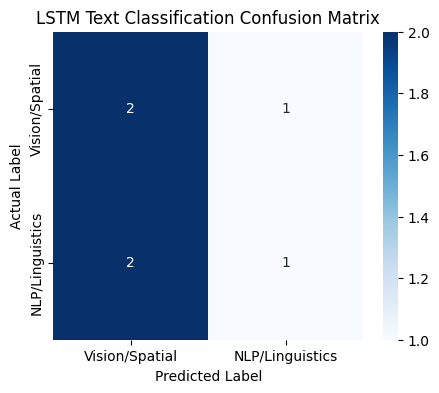

                 precision    recall  f1-score   support

 Vision/Spatial       0.50      0.67      0.57         3
NLP/Linguistics       0.50      0.33      0.40         3

       accuracy                           0.50         6
      macro avg       0.50      0.50      0.49         6
   weighted avg       0.50      0.50      0.49         6



In [12]:
cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=["Vision/Spatial", "NLP/Linguistics"],
    yticklabels=["Vision/Spatial", "NLP/Linguistics"]
)
plt.title("LSTM Text Classification Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Vision/Spatial", "NLP/Linguistics"],
    zero_division=0
))

---

# 11. Inference on Unseen Text

A real inference function must repeat the same preprocessing used during training.

In [13]:
def classify_text(raw_text):
    sequence = tokenizer.texts_to_sequences([raw_text])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    nlp_probability = nlp_model.predict(padded, verbose=0)[0][0]
    predicted_label = int(nlp_probability >= 0.5)

    category = "NLP/Linguistics" if predicted_label == 1 else "Vision/Spatial"
    confidence = nlp_probability if predicted_label == 1 else 1 - nlp_probability

    print(f"Text: {raw_text}")
    print(f"Token sequence: {sequence[0]}")
    print(f"Padded sequence: {padded[0]}")
    print(f"NLP probability: {nlp_probability:.4f}")
    print(f"Prediction: {category}")
    print(f"Confidence: {confidence * 100:.1f}%")
    print("-" * 80)

classify_text("Building a new tokenizer for Kannada language")
classify_text("Rendering three dimensional models for streetscape analysis")
classify_text("Using word embeddings for multilingual sentiment classification")
classify_text("Detecting pedestrians in traffic camera images")

Text: Building a new tokenizer for Kannada language
Token sequence: [78, 23, 1, 1, 2, 18, 1]
Padded sequence: [78 23  1  1  2 18  1  0  0  0  0  0]
NLP probability: 0.9184
Prediction: NLP/Linguistics
Confidence: 91.8%
--------------------------------------------------------------------------------
Text: Rendering three dimensional models for streetscape analysis
Token sequence: [1, 79, 80, 1, 2, 63, 4]
Padded sequence: [ 1 79 80  1  2 63  4  0  0  0  0  0]
NLP probability: 0.0007
Prediction: Vision/Spatial
Confidence: 99.9%
--------------------------------------------------------------------------------
Text: Using word embeddings for multilingual sentiment classification
Token sequence: [46, 21, 22, 2, 74, 19, 35]
Padded sequence: [46 21 22  2 74 19 35  0  0  0  0  0]
NLP probability: 0.9994
Prediction: NLP/Linguistics
Confidence: 99.9%
--------------------------------------------------------------------------------
Text: Detecting pedestrians in traffic camera images
Token sequence: 

## Important Warning

This is a small synthetic teaching dataset.

It demonstrates the pipeline, but it is not a production-quality classifier.

Real NLP systems require far more data and stronger evaluation.

---

# 12. Inspecting the Embedding Matrix

The embedding matrix shape is:

```text
vocabulary size × embedding dimensions
```

In [14]:
embedding_layer = nlp_model.layers[0]
embedding_weights = embedding_layer.get_weights()[0]

print("Embedding Matrix Shape:", embedding_weights.shape)

Embedding Matrix Shape: (1000, 16)


In [15]:
words_to_check = [
    "tokenization",
    "language",
    "image",
    "vision",
    "parser",
    "detection"
]

for word in words_to_check:
    if word in word_index:
        index = word_index[word]
        vector = embedding_weights[index]

        print(f"\nWord: {word}")
        print(f"Index: {index}")
        print("Vector:")
        print(np.round(vector, 3))
    else:
        print(f"'{word}' is not in the training vocabulary.")


Word: tokenization
Index: 45
Vector:
[-0.067  0.004 -0.084  0.031  0.024 -0.091  0.084  0.045 -0.019 -0.058
  0.057  0.079 -0.003  0.08  -0.046  0.055]
'language' is not in the training vocabulary.

Word: image
Index: 9
Vector:
[ 0.106 -0.106  0.016 -0.066 -0.095  0.054 -0.048 -0.077  0.032  0.096
 -0.025 -0.043  0.084 -0.106  0.08  -0.065]

Word: vision
Index: 60
Vector:
[-0.    -0.008  0.035 -0.066 -0.027  0.075 -0.073 -0.051  0.092  0.041
 -0.031 -0.037  0.033 -0.096  0.035 -0.093]
'parser' is not in the training vocabulary.

Word: detection
Index: 8
Vector:
[ 0.011 -0.092  0.089 -0.068 -0.028  0.026 -0.003 -0.033  0.106  0.082
 -0.065 -0.051  0.02  -0.043  0.11  -0.083]


---

# 13. Visualizing Embeddings in 2D

PCA compresses 16-dimensional vectors into 2 dimensions for plotting.

Because the dataset is small, the clusters may not be perfect.

The purpose is to demonstrate the workflow.

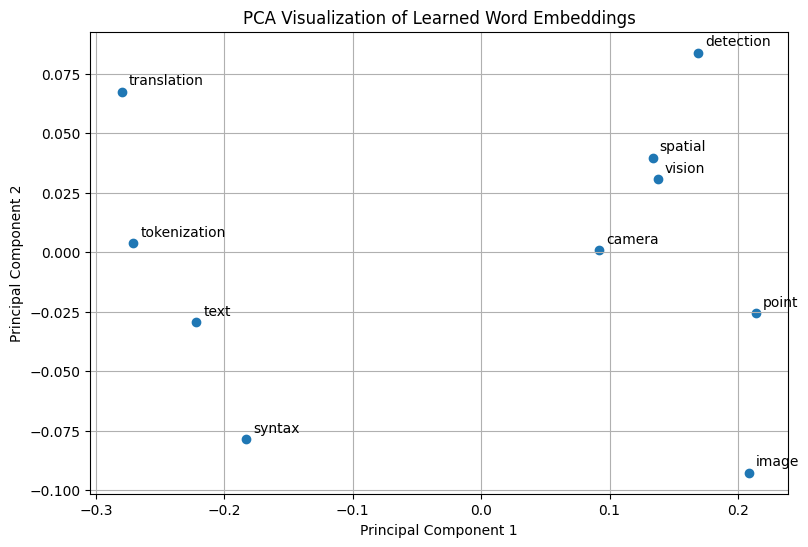

In [16]:
selected_words = [
    word for word in [
        "language", "tokenization", "parser", "syntax",
        "image", "vision", "detection", "spatial",
        "translation", "camera", "text", "point"
    ]
    if word in word_index
]

selected_vectors = np.array([
    embedding_weights[word_index[word]]
    for word in selected_words
])

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(selected_vectors)

plt.figure(figsize=(9, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for word, (x, y) in zip(selected_words, vectors_2d):
    plt.annotate(word, (x, y), xytext=(5, 5), textcoords="offset points")

plt.title("PCA Visualization of Learned Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

---

# 14. Sequence-to-Sequence Summarization Concept

## Important Clarification

The function below is a simulation, not a trained summarization model.

Our current model is a classifier.

True summarization requires an encoder-decoder architecture and target summaries.

In [17]:
def generate_summary_demo(complex_text):
    print("Encoder reads the document context...")
    print("Decoder would generate one token at a time...")

    return (
        "The study presents a neural morphological parser for Dravidian languages. "
        "It reduces out-of-vocabulary errors and improves performance over statistical baselines."
    )

long_document = '''
This research investigates morphological richness in Dravidian languages.
The authors apply deep learning to reduce out-of-vocabulary errors and
report improved performance over traditional statistical models.
'''

print("--- Original Text ---")
print(long_document.strip())

print("\n--- Simulated Summary ---")
print(generate_summary_demo(long_document))

--- Original Text ---
This research investigates morphological richness in Dravidian languages.
The authors apply deep learning to reduce out-of-vocabulary errors and
report improved performance over traditional statistical models.

--- Simulated Summary ---
Encoder reads the document context...
Decoder would generate one token at a time...
The study presents a neural morphological parser for Dravidian languages. It reduces out-of-vocabulary errors and improves performance over statistical baselines.


---

# 15. Complete Pipeline Summary

```text
Raw Text
   ↓
Tokenizer
   ↓
Integer Sequences
   ↓
Padding
   ↓
Embedding Layer
   ↓
LSTM
   ↓
Dense Classifier
   ↓
Probability
   ↓
Final Category
```

In [18]:
steps = [
    "1. Raw text",
    "2. Vocabulary creation",
    "3. Integer sequences",
    "4. Padding",
    "5. Embeddings",
    "6. LSTM sequence processing",
    "7. Dense classification",
    "8. Probability and label"
]

for step in steps:
    print(step)

1. Raw text
2. Vocabulary creation
3. Integer sequences
4. Padding
5. Embeddings
6. LSTM sequence processing
7. Dense classification
8. Probability and label


---

# Day 14 Hands-On Coding Test

No solutions are provided in this section.

# Test 1: Easy — Tokenization and Padding

Use:

```python
sentences = [
    "deep learning for text",
    "computer vision with images",
    "language models process sequences"
]
```

Tasks:

1. Create a tokenizer with `<OOV>`
2. Fit it on the sentences
3. Print the word index
4. Convert texts to sequences
5. Pad to length 6 using post-padding
6. Print the padded matrix

In [ ]:
# Test 1 Student Code

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sentences = [
    "deep learning for text",
    "computer vision with images",
    "language models process sequences"
]

# Write your solution here

# Test 2: Medium — Build an LSTM Model

Build a model with:

- Input length 15
- Vocabulary size 2000
- Embedding dimension 32
- LSTM with 64 units
- Dense with 16 ReLU neurons
- One sigmoid output
- Adam optimizer
- Binary cross-entropy loss

In [ ]:
# Test 2 Student Code

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# Write your solution here

# Test 3: Hard — Complete Text Classification Pipeline

Use:

```python
texts = [
    "tokenization for language models",
    "syntax parsing for text",
    "sentiment analysis using embeddings",
    "object detection in images",
    "image segmentation using cnn",
    "lidar point cloud processing"
]

labels = [1, 1, 1, 0, 0, 0]
```

Tasks:

1. Tokenize
2. Convert to sequences
3. Pad to length 8
4. Build Embedding + LSTM + Dense model
5. Train for 30 epochs
6. Print final accuracy
7. Create a prediction function
8. Test two new sentences

In [ ]:
# Test 3 Student Code

import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

texts = [
    "tokenization for language models",
    "syntax parsing for text",
    "sentiment analysis using embeddings",
    "object detection in images",
    "image segmentation using cnn",
    "lidar point cloud processing"
]

labels = np.array([1, 1, 1, 0, 0, 0])

# Write your solution here

---

# End of Day 14 Notebook

Students should now understand:

- Tokenization
- Vocabulary creation
- OOV tokens
- Integer sequences
- Padding
- Embeddings
- LSTMs
- Binary text classification
- Inference
- Embedding visualization
- Why true summarization needs a different architecture